In [1]:
# ==============================================================================
# Experiment 3: Implementation of Convolutional Neural Networks (CNNs)
# ==============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Configure Device for Kaggle GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hardware Accelerator configured: {device}")

# Ensure reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Global visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

Hardware Accelerator configured: cpu


100%|██████████| 170M/170M [45:05<00:00, 63.0kB/s]



--- Dataset Dimensions ---
Total Training Images : 50000
Total Testing Images  : 10000
Image Tensor Shape    : torch.Size([3, 32, 32]) (Channels x Height x Width)
Number of Classes     : 10


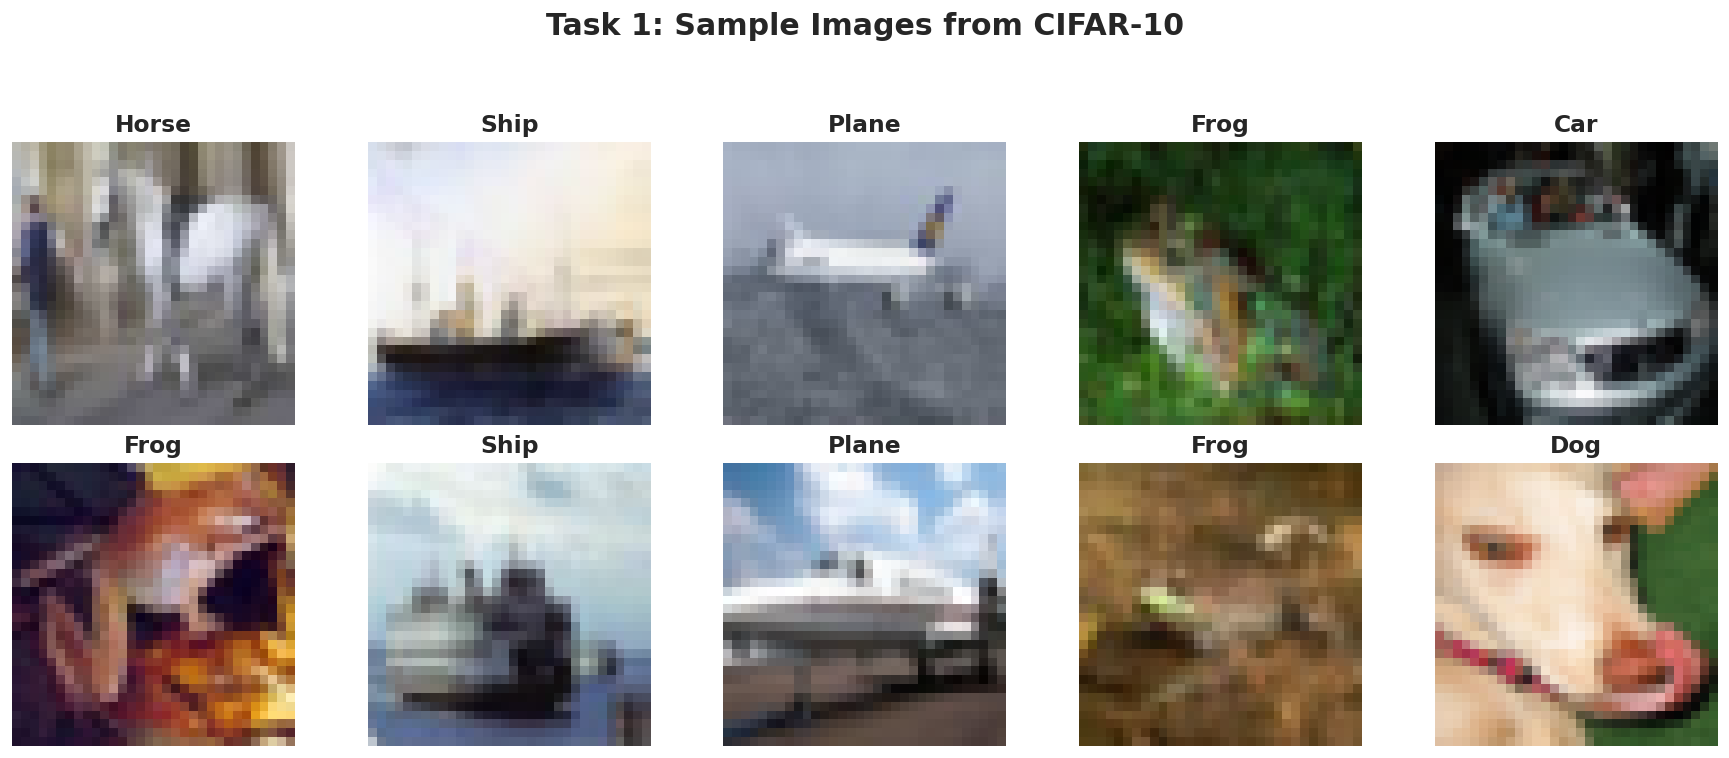

/tmp/ipykernel_1442/4128795216.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=train_labels_list, palette="viridis")
/tmp/ipykernel_1442/4128795216.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cifar10_classes, rotation=45)


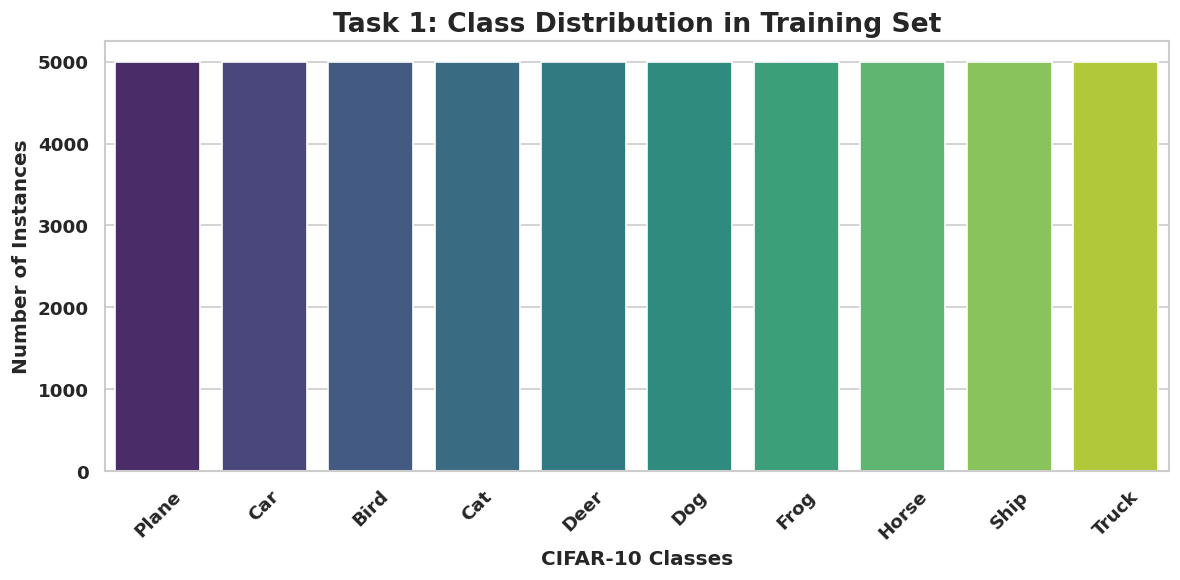

In [2]:
# Task 1: Dataset Exploration
# Define the classes present in CIFAR-10
cifar10_classes = ['Plane', 'Car', 'Bird', 'Cat', 'Deer',
                   'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Define basic transform (converting to Tensor scales pixels to [0, 1])
base_transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load datasets
print("Downloading CIFAR-10 dataset...")
cifar_train = torchvision.datasets.CIFAR10(root='./dataset', train=True, download=True, transform=base_transform)
cifar_test = torchvision.datasets.CIFAR10(root='./dataset', train=False, download=True, transform=base_transform)

# Print Dataset Dimensions
print("\n--- Dataset Dimensions ---")
print(f"Total Training Images : {len(cifar_train)}")
print(f"Total Testing Images  : {len(cifar_test)}")
print(f"Image Tensor Shape    : {cifar_train[0][0].shape} (Channels x Height x Width)")
print(f"Number of Classes     : {len(cifar10_classes)}")

# Visualize 10 sample images (randomly selected)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
indices = np.random.choice(len(cifar_train), 10, replace=False)

for idx, ax in zip(indices, axes.ravel()):
    img_tensor, label_idx = cifar_train[idx]
    # Convert from (C, H, W) to (H, W, C) for Matplotlib
    img_display = img_tensor.permute(1, 2, 0).numpy()

    ax.imshow(img_display)
    ax.set_title(cifar10_classes[label_idx], fontsize=14, weight='bold')
    ax.axis('off')

plt.suptitle("Task 1: Sample Images from CIFAR-10", fontsize=18, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Plot Class Distribution
# Extract all labels from the training set
train_labels_list = [label for _, label in cifar_train]

plt.figure(figsize=(10, 5))
ax = sns.countplot(x=train_labels_list, palette="viridis")
ax.set_xticklabels(cifar10_classes, rotation=45)
plt.title("Task 1: Class Distribution in Training Set", fontsize=16, weight='bold')
plt.xlabel("CIFAR-10 Classes", weight='bold')
plt.ylabel("Number of Instances", weight='bold')
plt.tight_layout()
plt.show()

In [3]:
# ==============================================================================
# Task 2 & 3: Convolution, Stride, and Padding Analysis
# ==============================================================================

# Helper function to compute output dimension mathematically
def calc_output_size(input_dim, kernel_size, padding, stride):
    """
    Computes the spatial output dimension of a convolutional layer.
    Formula: Output Size = ((N - F + 2P) / S) + 1
    """
    return ((input_dim - kernel_size + 2 * padding) // stride) + 1

# Extract a single sample image and add batch dimension (B, C, H, W)
sample_img, _ = cifar_train[0]
sample_batch = sample_img.unsqueeze(0).to(device)

input_size = sample_batch.shape[2] # 32 (since CIFAR-10 is 32x32)

print("--- Task 2: Convolution Kernel Size Comparison ---")
print(f"Input spatial dimensions: {input_size}x{input_size}\n")
print(f"{'Kernel Size':<15} | {'Mathematical Output':<25} | {'Actual Tensor Shape'}")
print("-" * 70)

kernel_variations = [3, 5, 7]

# Testing different kernel sizes (assuming Stride=1, Padding=0)
for k in kernel_variations:
    # Initialize Conv layer
    conv_layer = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=k, stride=1, padding=0).to(device)

    # Pass image through layer
    out_tensor = conv_layer(sample_batch)
    actual_shape = f"{out_tensor.shape[2]}x{out_tensor.shape[3]}"

    # Calculate mathematically
    math_dim = calc_output_size(input_size, k, padding=0, stride=1)
    math_shape = f"{math_dim}x{math_dim}"

    print(f"{k}x{k:<13} | {math_shape:<25} | {actual_shape}")


print("\n\n--- Task 3: Stride and Padding Study ---")
print("Using a standard 3x3 kernel.\n")
print(f"{'Configuration':<35} | {'Formula Output':<15} | {'Actual Tensor'}")
print("-" * 75)

# Testing hyperparameter combinations: (stride, padding, padding_type)
hyperparameters = [
    (1, 0, "Valid (0)"),
    (2, 0, "Valid (0)"),
    (1, 1, "Same (1)"),
    (2, 1, "Same-ish (1)")
]

for stride_val, pad_val, pad_name in hyperparameters:
    config_name = f"Stride={stride_val}, Padding={pad_name}"

    # Initialize Conv layer
    conv_layer = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3,
                           stride=stride_val, padding=pad_val).to(device)

    # Pass image through layer
    out_tensor = conv_layer(sample_batch)
    actual_shape = f"{out_tensor.shape[2]}x{out_tensor.shape[3]}"

    # Calculate mathematically
    math_dim = calc_output_size(input_size, kernel_size=3, padding=pad_val, stride=stride_val)
    math_shape = f"{math_dim}x{math_dim}"

    print(f"{config_name:<35} | {math_shape:<15} | {actual_shape}")

--- Task 2: Convolution Kernel Size Comparison ---
Input spatial dimensions: 32x32

Kernel Size     | Mathematical Output       | Actual Tensor Shape
----------------------------------------------------------------------
3x3             | 30x30                     | 30x30
5x5             | 28x28                     | 28x28
7x7             | 26x26                     | 26x26


--- Task 3: Stride and Padding Study ---
Using a standard 3x3 kernel.

Configuration                       | Formula Output  | Actual Tensor
---------------------------------------------------------------------------
Stride=1, Padding=Valid (0)         | 30x30           | 30x30
Stride=2, Padding=Valid (0)         | 15x15           | 15x15
Stride=1, Padding=Same (1)          | 32x32           | 32x32
Stride=2, Padding=Same-ish (1)      | 16x16           | 16x16


--- Task 4: Feature Map Visualization ---


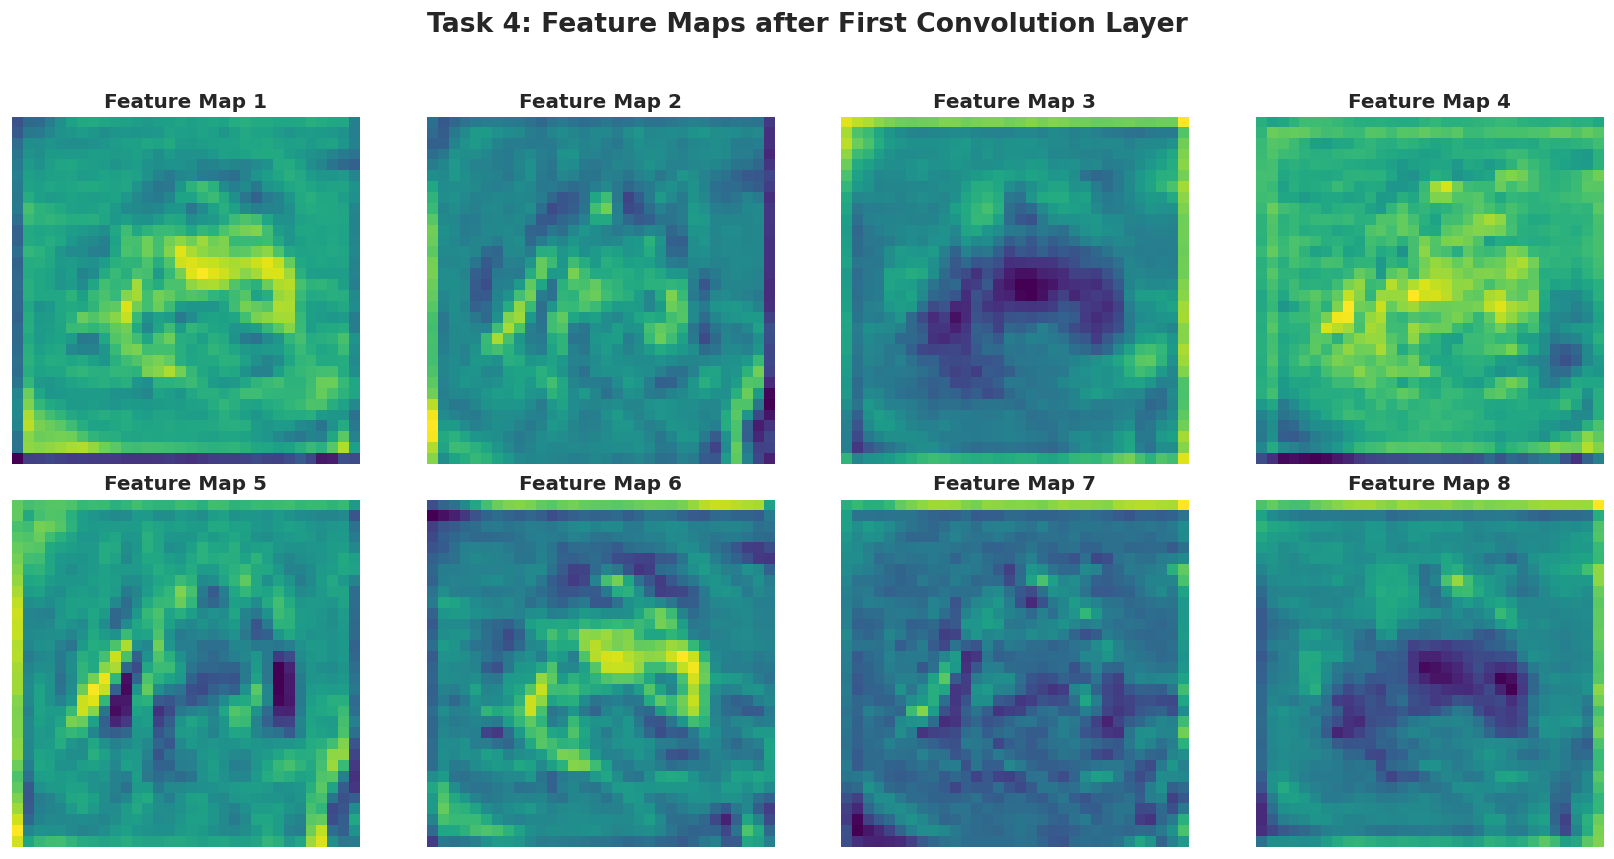


--- Task 5: Pooling Comparison ---
Original Feature Map Size : [32, 32]
Size after Max Pooling    : [16, 16]
Size after Avg Pooling    : [16, 16]



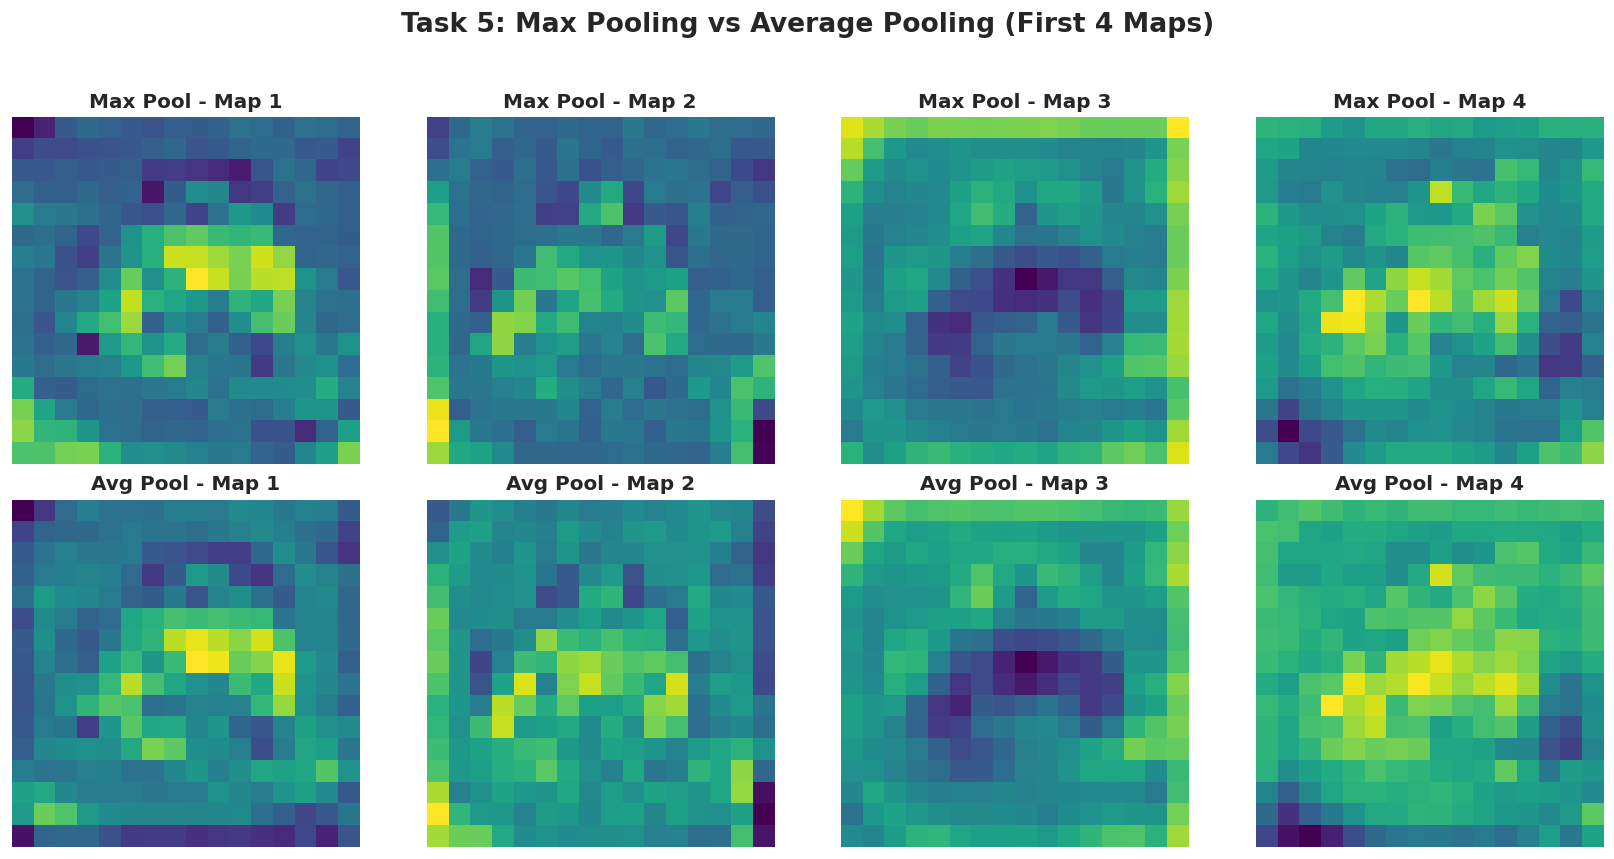

In [4]:
# ==============================================================================
# Task 4 & 5: Feature Map Visualization and Pooling Comparison
# ==============================================================================

# ---------------------------------------------------------
# Task 4: Feature Map Visualization
# ---------------------------------------------------------
print("--- Task 4: Feature Map Visualization ---")

# Define a standard 1st convolution layer (3 input channels -> 16 output channels)
# Using padding=1 to keep the spatial dimension at 32x32
conv1_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1).to(device)

# Forward pass (using torch.no_grad() since we aren't training yet)
with torch.no_grad():
    feature_maps_tensor = conv1_layer(sample_batch)

# Move the tensor to CPU and remove the batch dimension for plotting
# Shape changes from (1, 16, 32, 32) to (16, 32, 32)
fmaps_display = feature_maps_tensor.squeeze(0).cpu()

# Display at least 8 feature maps (we'll do a 2x4 grid)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, ax in enumerate(axes.ravel()):
    # We plot the i-th feature map
    ax.imshow(fmaps_display[i], cmap='viridis')
    ax.set_title(f"Feature Map {i+1}", fontsize=12, weight='bold')
    ax.axis('off')

plt.suptitle("Task 4: Feature Maps after First Convolution Layer", fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Task 5: Pooling Comparison
# ---------------------------------------------------------
print("\n--- Task 5: Pooling Comparison ---")

# Define the two types of pooling (kernel=2, stride=2 halves the dimensions)
max_pool_layer = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool_layer = nn.AvgPool2d(kernel_size=2, stride=2)

# Apply pooling to our generated feature maps
with torch.no_grad():
    fmaps_max = max_pool_layer(feature_maps_tensor)
    fmaps_avg = avg_pool_layer(feature_maps_tensor)

# Compare Output Sizes
print(f"Original Feature Map Size : {list(feature_maps_tensor.shape[2:])}")
print(f"Size after Max Pooling    : {list(fmaps_max.shape[2:])}")
print(f"Size after Avg Pooling    : {list(fmaps_avg.shape[2:])}\n")

# Prepare for visualization
fmaps_max_display = fmaps_max.squeeze(0).cpu()
fmaps_avg_display = fmaps_avg.squeeze(0).cpu()

# Plot to compare feature representation (Sharpness vs. Smoothing)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Pick the first 4 feature maps to compare directly
for i in range(4):
    # Top Row: Max Pooling (Should preserve sharp edges and highest activations)
    axes[0, i].imshow(fmaps_max_display[i], cmap='viridis')
    axes[0, i].set_title(f"Max Pool - Map {i+1}", fontsize=12, weight='bold')
    axes[0, i].axis('off')

    # Bottom Row: Average Pooling (Should look blurrier/smoother)
    axes[1, i].imshow(fmaps_avg_display[i], cmap='viridis')
    axes[1, i].set_title(f"Avg Pool - Map {i+1}", fontsize=12, weight='bold')
    axes[1, i].axis('off')

plt.suptitle("Task 5: Max Pooling vs Average Pooling (First 4 Maps)", fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# ==============================================================================
# Task 6: CNN Construction and Training
# ==============================================================================

# ---------------------------------------------------------
# 1. Data Preparation (Batch Size = 32)
# ---------------------------------------------------------
BATCH_SIZE = 32 # Set as per requirements

# Split the 50,000 training images into 40,000 Train and 10,000 Validation
val_size = 10000
train_size = len(cifar_train) - val_size
train_subset, val_subset = random_split(cifar_train, [train_size, val_size])

# Initialize DataLoaders to feed data in batches
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(cifar_test, batch_size=BATCH_SIZE, shuffle=False)

# ---------------------------------------------------------
# 2. CNN Architecture Definition
# Architecture: Input -> Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Softmax
# ---------------------------------------------------------
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super(CIFAR10_CNN, self).__init__()

        # Block 1: Conv -> MaxPool
        # Input: 3x32x32. Output: 16x32x32 (padding=1 keeps spatial dims)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        # Output: 16x16x16 (kernel 2, stride 2 halves spatial dims)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: Conv -> MaxPool
        # Input: 16x16x16. Output: 32x16x16
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Output: 32x8x8
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Flattening Layer
        self.flatten = nn.Flatten()

        # Dense (Fully Connected) Layer
        # Input features: 32 channels * 8 height * 8 width = 2048
        self.fc1 = nn.Linear(32 * 8 * 8, 10)

        # NOTE: PyTorch's nn.CrossEntropyLoss automatically applies Softmax internally.
        # Therefore, we output raw logits from the Dense layer to ensure numerical stability.

    def forward(self, x):
        # Pass through Block 1 with ReLU activation
        x = self.pool1(F.relu(self.conv1(x)))
        # Pass through Block 2 with ReLU activation
        x = self.pool2(F.relu(self.conv2(x)))
        # Flatten for Dense layer
        x = self.flatten(x)
        # Pass through Dense layer
        x = self.fc1(x)
        return x

# Instantiate model and move to Kaggle GPU
model = CIFAR10_CNN().to(device)

# Calculate and print total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params}")

# ---------------------------------------------------------
# 3. Training Setup (Optimizer: Adam, Epochs: 20)
# ---------------------------------------------------------
EPOCHS = 20
learning_rate = 0.001

criterion = nn.CrossEntropyLoss() # Combines Softmax and Negative Log-Likelihood
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Dictionary to store metrics for Plotting in Task 7
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"\nStarting Training on {device} for {EPOCHS} Epochs...")

# ---------------------------------------------------------
# 4. Training Loop
# ---------------------------------------------------------
for epoch in range(EPOCHS):

    # -- TRAIN PHASE --
    model.train() # Enable gradient tracking and dropout/batchnorm (if any)
    running_train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # Clear old gradients
        outputs = model(images)         # Forward pass
        loss = criterion(outputs, labels) # Compute loss
        loss.backward()                 # Backward pass (calculate gradients)
        optimizer.step()                # Update weights

        # Track metrics
        running_train_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1) # Get highest probability class
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    epoch_train_loss = running_train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # -- VALIDATION PHASE --
    model.eval() # Disable gradient tracking for faster/lighter computation
    running_val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad(): # Explicitly tell PyTorch not to build computation graph
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Track metrics
            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = running_val_loss / val_total
    epoch_val_acc = val_correct / val_total

    # -- RECORD & PRINT --
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

Total Trainable Parameters: 25578

Starting Training on cpu for 20 Epochs...
Epoch [01/20] Train Loss: 1.5963, Train Acc: 0.4318 | Val Loss: 1.3710, Val Acc: 0.5111
Epoch [02/20] Train Loss: 1.2904, Train Acc: 0.5439 | Val Loss: 1.1795, Val Acc: 0.5874
Epoch [03/20] Train Loss: 1.1484, Train Acc: 0.5972 | Val Loss: 1.1041, Val Acc: 0.6173
Epoch [04/20] Train Loss: 1.0587, Train Acc: 0.6319 | Val Loss: 1.0489, Val Acc: 0.6333
Epoch [05/20] Train Loss: 0.9990, Train Acc: 0.6533 | Val Loss: 1.0323, Val Acc: 0.6415
Epoch [06/20] Train Loss: 0.9536, Train Acc: 0.6710 | Val Loss: 1.0046, Val Acc: 0.6524
Epoch [07/20] Train Loss: 0.9210, Train Acc: 0.6811 | Val Loss: 1.0035, Val Acc: 0.6488
Epoch [08/20] Train Loss: 0.8950, Train Acc: 0.6909 | Val Loss: 1.0149, Val Acc: 0.6479
Epoch [09/20] Train Loss: 0.8706, Train Acc: 0.6991 | Val Loss: 0.9738, Val Acc: 0.6592
Epoch [10/20] Train Loss: 0.8488, Train Acc: 0.7068 | Val Loss: 0.9961, Val Acc: 0.6593
Epoch [11/20] Train Loss: 0.8283, Train Acc

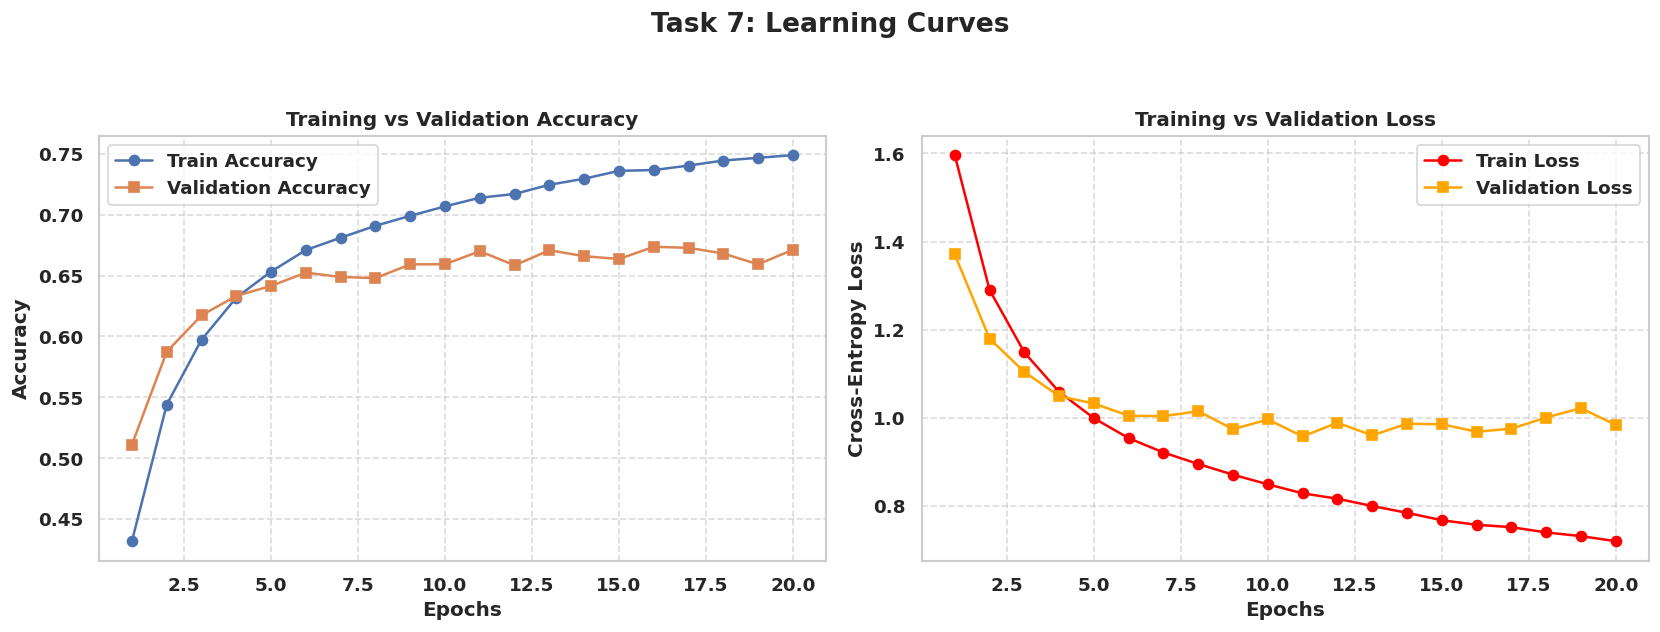


--- Running Inference on Test Set (10,000 images) ---

--- Task 7: Test Set Results ---
Accuracy         : 0.6704
Precision (macro): 0.6719
Recall (macro)   : 0.6704
F1-score (macro) : 0.6701
Total Parameters : 25578

--- Detailed Classification Report ---
              precision    recall  f1-score   support

       Plane       0.65      0.76      0.70      1000
         Car       0.81      0.75      0.78      1000
        Bird       0.57      0.54      0.55      1000
         Cat       0.50      0.49      0.50      1000
        Deer       0.63      0.62      0.63      1000
         Dog       0.59      0.57      0.58      1000
        Frog       0.74      0.73      0.74      1000
       Horse       0.76      0.71      0.73      1000
        Ship       0.79      0.74      0.76      1000
       Truck       0.69      0.78      0.73      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.67     10000
weighted avg       0.67      0.67     

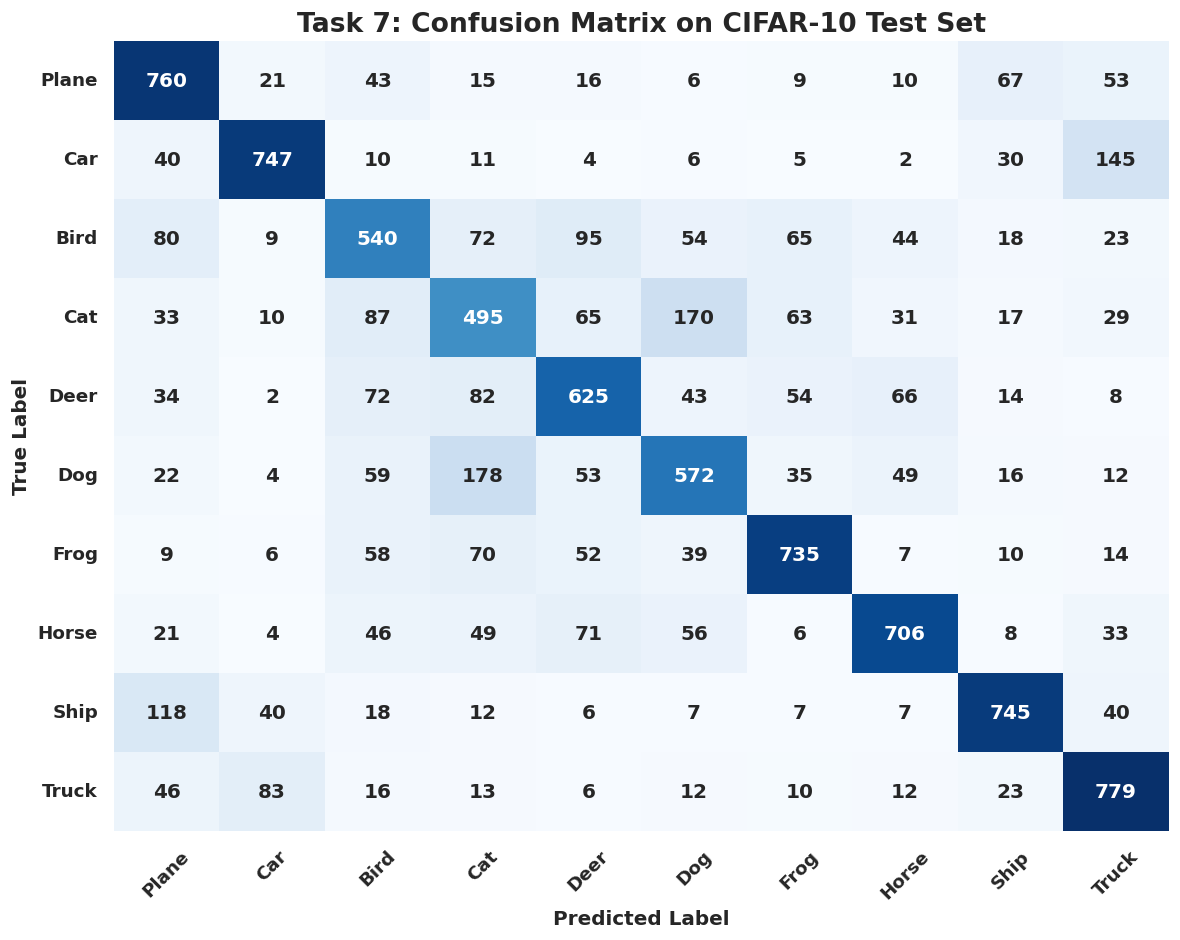

In [6]:
# ==============================================================================
# Task 7: Model Evaluation & Visualization
# ==============================================================================

# ---------------------------------------------------------
# 1. Plotting Learning Curves (Accuracy & Loss)
# ---------------------------------------------------------
# Extract epoch sequence (1 to 20) for the X-axis
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Training and Validation Accuracy vs. Epoch
axes[0].plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
axes[0].plot(epochs_range, history['val_acc'], label='Validation Accuracy', marker='s')
axes[0].set_title("Training vs Validation Accuracy", weight='bold')
axes[0].set_xlabel("Epochs", weight='bold')
axes[0].set_ylabel("Accuracy", weight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Training and Validation Loss vs. Epoch
axes[1].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', color='red')
axes[1].plot(epochs_range, history['val_loss'], label='Validation Loss', marker='s', color='orange')
axes[1].set_title("Training vs Validation Loss", weight='bold')
axes[1].set_xlabel("Epochs", weight='bold')
axes[1].set_ylabel("Cross-Entropy Loss", weight='bold')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Task 7: Learning Curves", fontsize=16, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 2. Test Set Inference
# ---------------------------------------------------------
print("\n--- Running Inference on Test Set (10,000 images) ---")
model.eval() # Ensure the model is in evaluation mode

true_labels = []
predicted_labels = []

# Disable gradient calculation to speed up inference and save memory
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        _, preds = torch.max(outputs, 1) # Extract the class index with highest probability

        # Move tensors back to CPU and convert to NumPy arrays for Scikit-Learn
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(preds.cpu().numpy())

# ---------------------------------------------------------
# 3. Calculating Evaluation Metrics
# ---------------------------------------------------------
# Compute macro-averaged metrics to treat all classes equally
test_accuracy = accuracy_score(true_labels, predicted_labels)
test_precision = precision_score(true_labels, predicted_labels, average='macro')
test_recall = recall_score(true_labels, predicted_labels, average='macro')
test_f1 = f1_score(true_labels, predicted_labels, average='macro')

print("\n--- Task 7: Test Set Results ---")
print(f"Accuracy         : {test_accuracy:.4f}")
print(f"Precision (macro): {test_precision:.4f}")
print(f"Recall (macro)   : {test_recall:.4f}")
print(f"F1-score (macro) : {test_f1:.4f}")
print(f"Total Parameters : {total_params}") # Required parameter logging

# ---------------------------------------------------------
# 4. Classification Report & Confusion Matrix
# ---------------------------------------------------------
print("\n--- Detailed Classification Report ---")
print(classification_report(true_labels, predicted_labels, target_names=cifar10_classes))

# Generate the Confusion Matrix array
cm = confusion_matrix(true_labels, predicted_labels)

# Plot Confusion Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cifar10_classes, yticklabels=cifar10_classes, cbar=False)

plt.title("Task 7: Confusion Matrix on CIFAR-10 Test Set", fontsize=16, weight='bold')
plt.xlabel("Predicted Label", fontsize=12, weight='bold')
plt.ylabel("True Label", fontsize=12, weight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()